<a href="https://colab.research.google.com/github/samiha-binte/Capstone-/blob/main/Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
!pip install -q kagglehub


In [ ]:
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/heart-failure-prediction


In [ ]:
import pandas as pd
import os

# The CSV file is typically named "heart.csv" inside the dataset folder
csv_path = os.path.join(path, "heart.csv")

df = pd.read_csv(csv_path)
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
# Replace 0s in important columns (already done, but repeat to be safe)
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], drop_first=True)


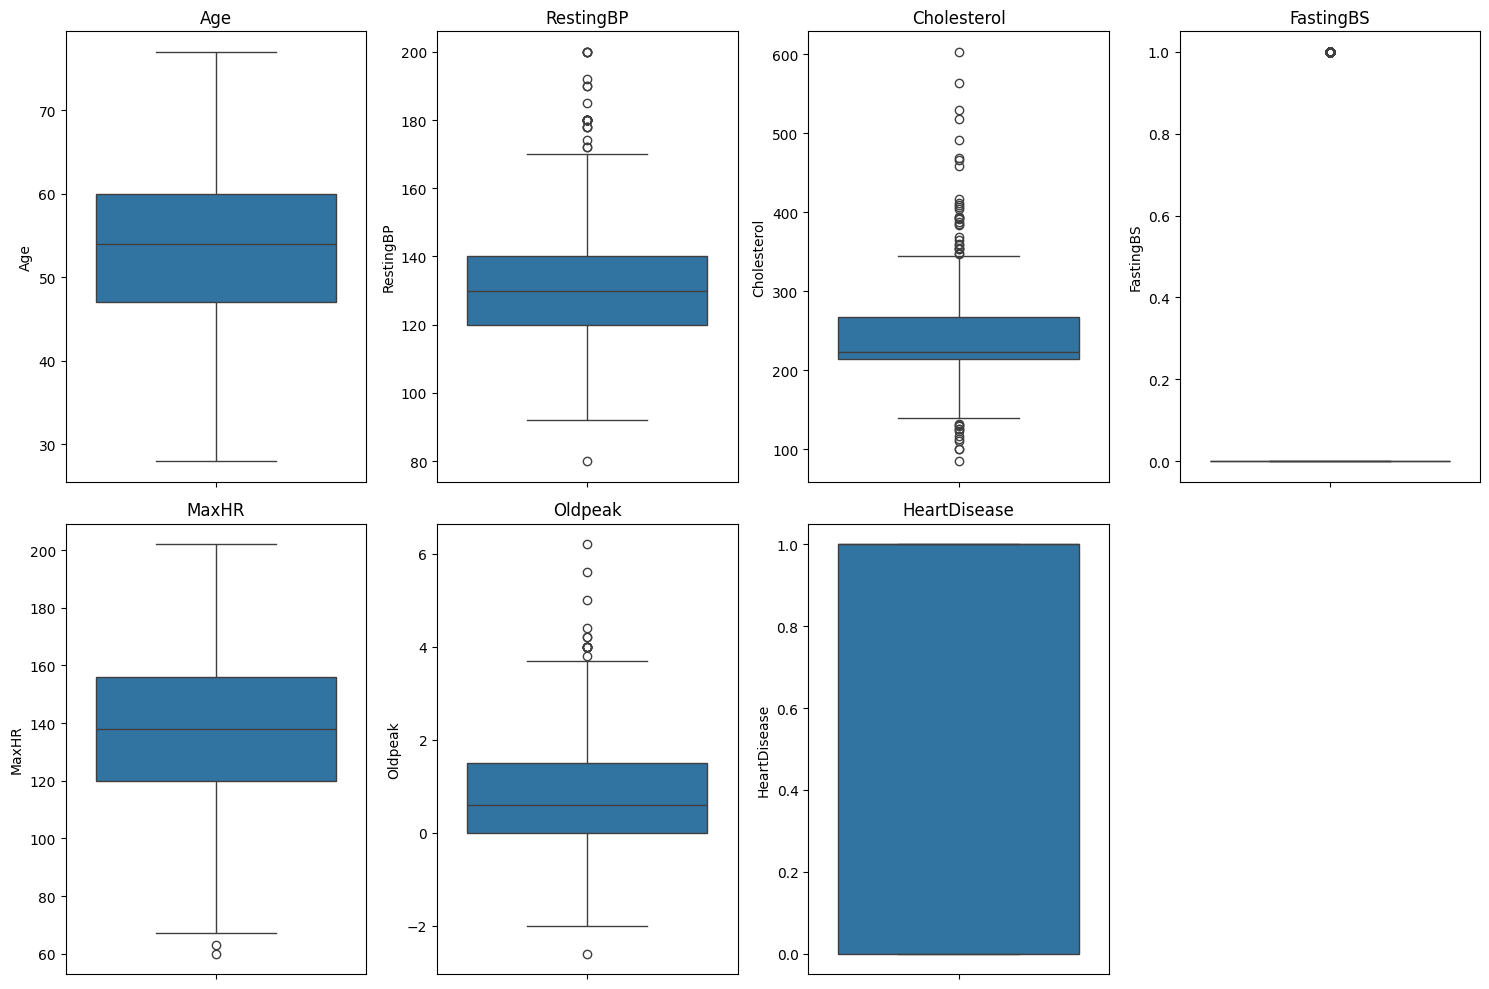

In [ ]:
# Select only numerical columns for outlier detection
numerical_cols = df_encoded.select_dtypes(include=np.number).columns

# Create box plots for each numerical column to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols) // 4 + 1, 4, i + 1)
    sns.boxplot(y=df_encoded[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Handle Outliers using IQR

In [ ]:
# Function to remove outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)].reset_index(drop=True)
    return df_cleaned

# Apply outlier removal to numerical columns in the encoded dataframe
numerical_cols_to_clean = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'] # Exclude one-hot encoded columns

df_cleaned = df_encoded.copy()
for col in numerical_cols_to_clean:
    df_cleaned = remove_outliers_iqr(df_cleaned, col)

print(f"Original number of rows: {len(df_encoded)}")
print(f"Number of rows after outlier removal: {len(df_cleaned)}")

display(df_cleaned.head())

Original number of rows: 918
Number of rows after outlier removal: 643


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


Handle Outliers and Encode Categorical Features

In [ ]:
# Replace 0s in 'RestingBP' and 'Cholesterol' with the median
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], drop_first=True)

display(df_encoded.head())

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


Now calculate and visualize the correlation matrix with the encoded data.

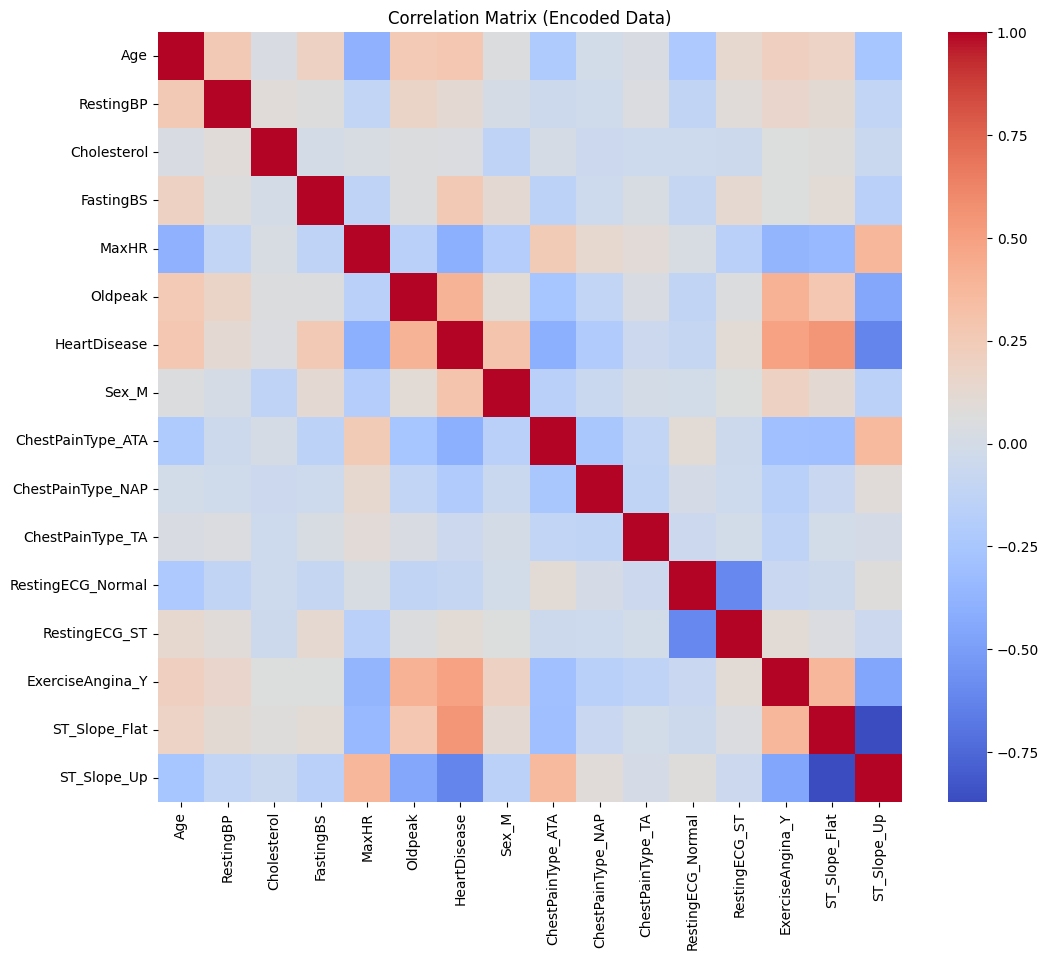

In [ ]:
# Correlation matrix on the encoded data
plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix (Encoded Data)')
plt.show()

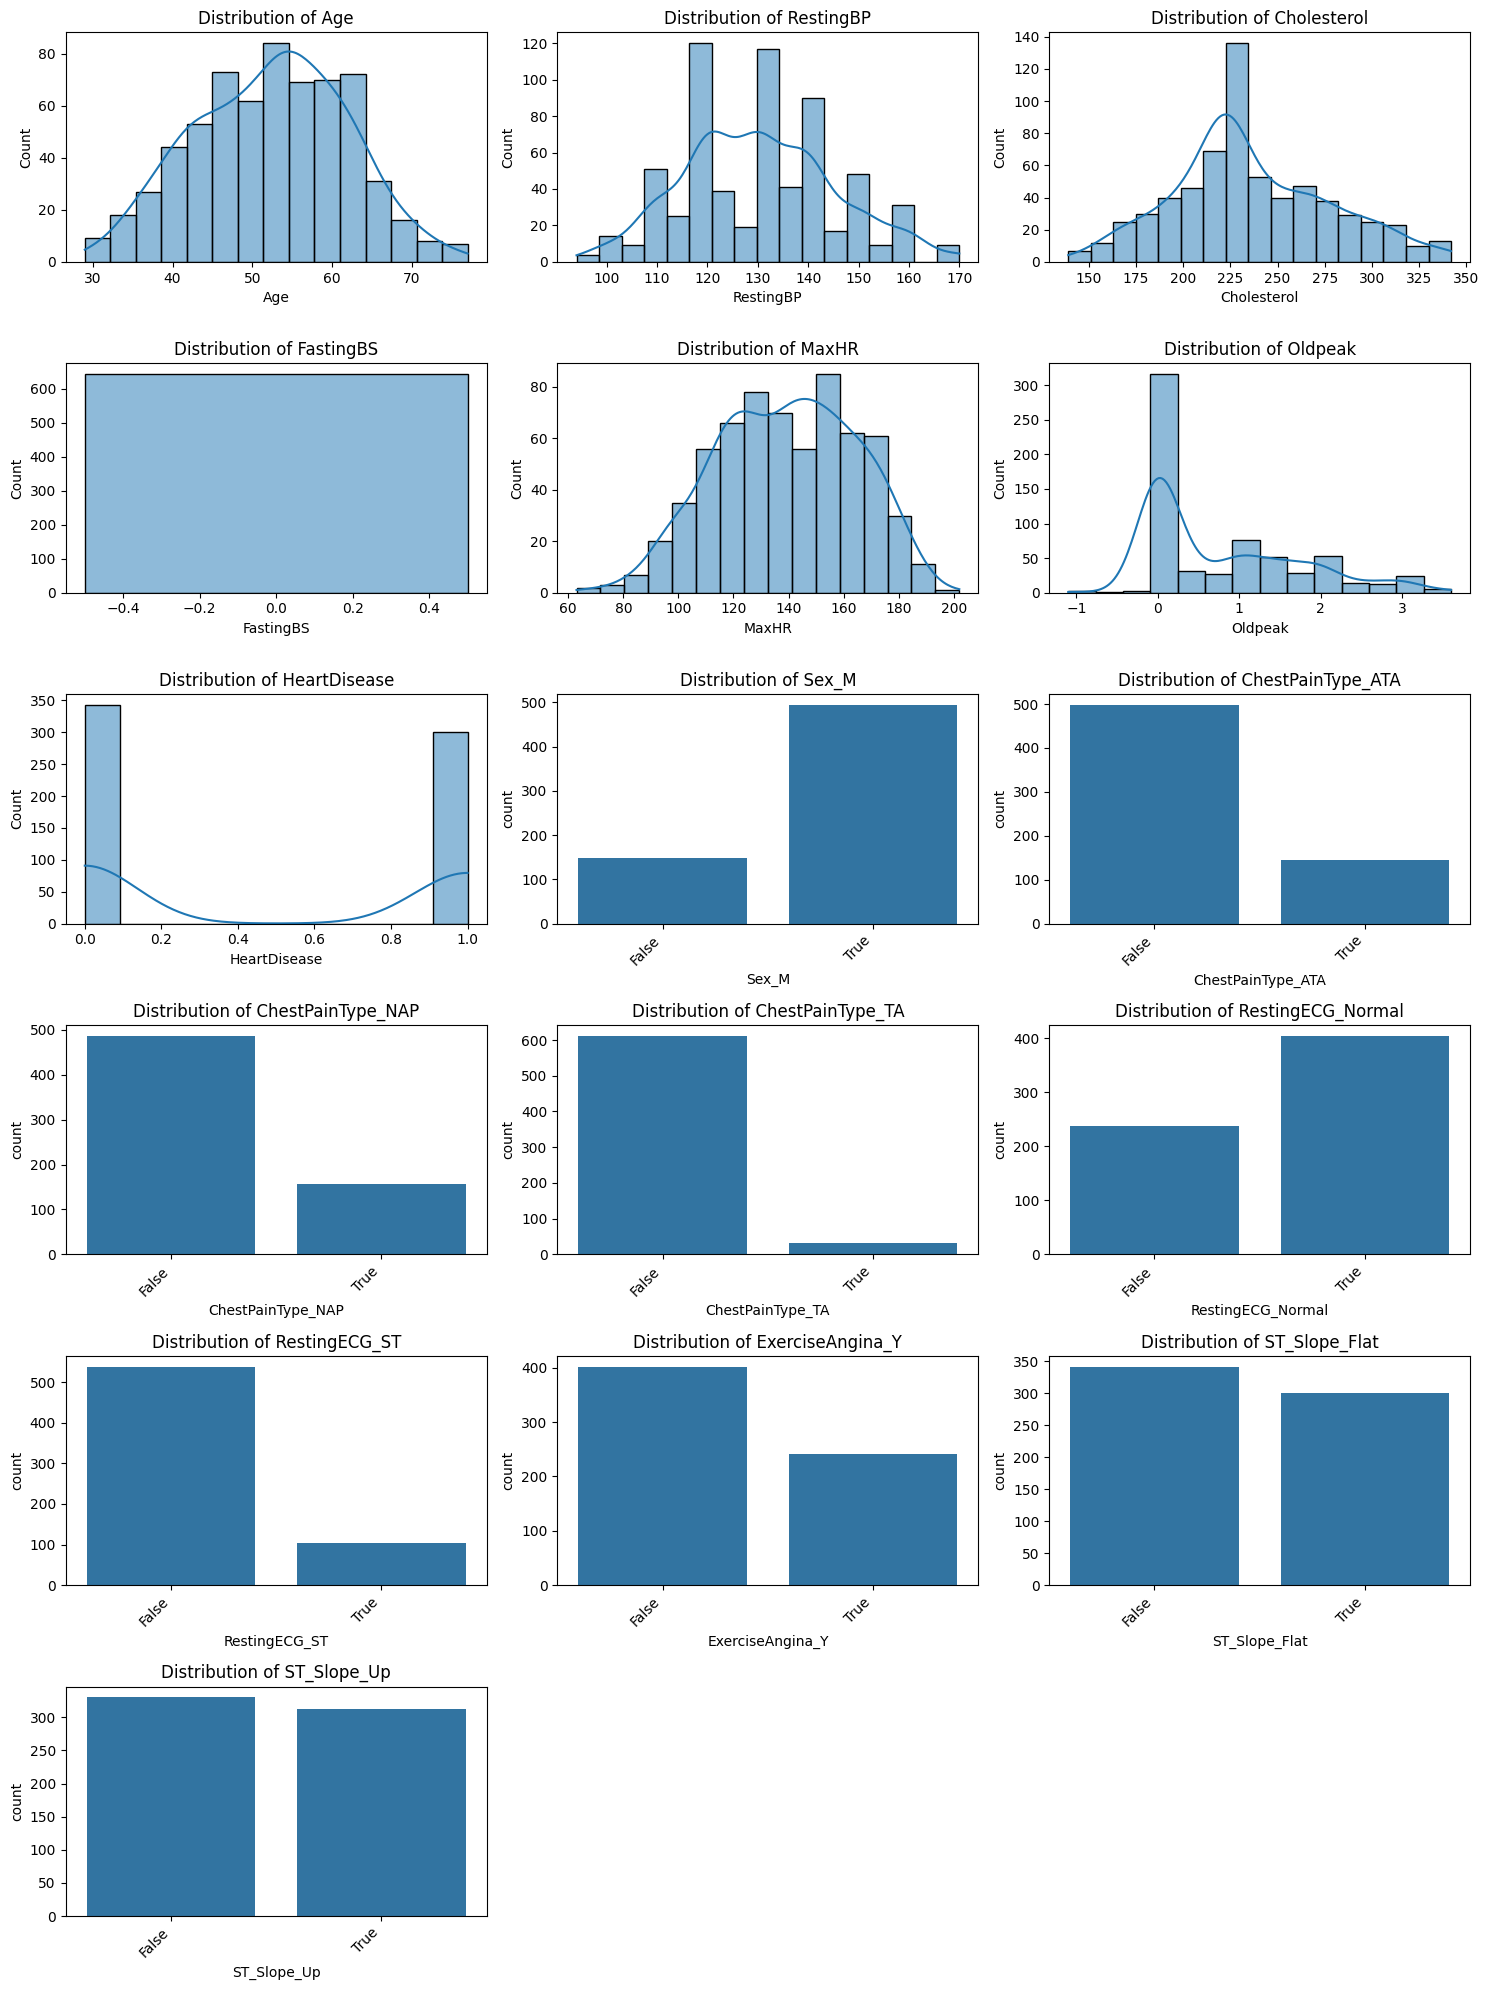

In [ ]:
# Visualize the distribution of individual features
plt.figure(figsize=(15, 20))
for i, col in enumerate(df_cleaned.columns):
    if df_cleaned[col].dtype in ['int64', 'float64', 'int32']:
        # Histogram for numerical columns
        plt.subplot(len(df_cleaned.columns) // 3 + 1, 3, i + 1)
        sns.histplot(df_cleaned[col], kde=True)
        plt.title(f'Distribution of {col}')
    else:
        # Count plot for categorical columns
        plt.subplot(len(df_cleaned.columns) // 3 + 1, 3, i + 1)
        sns.countplot(x=df_cleaned[col])
        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()



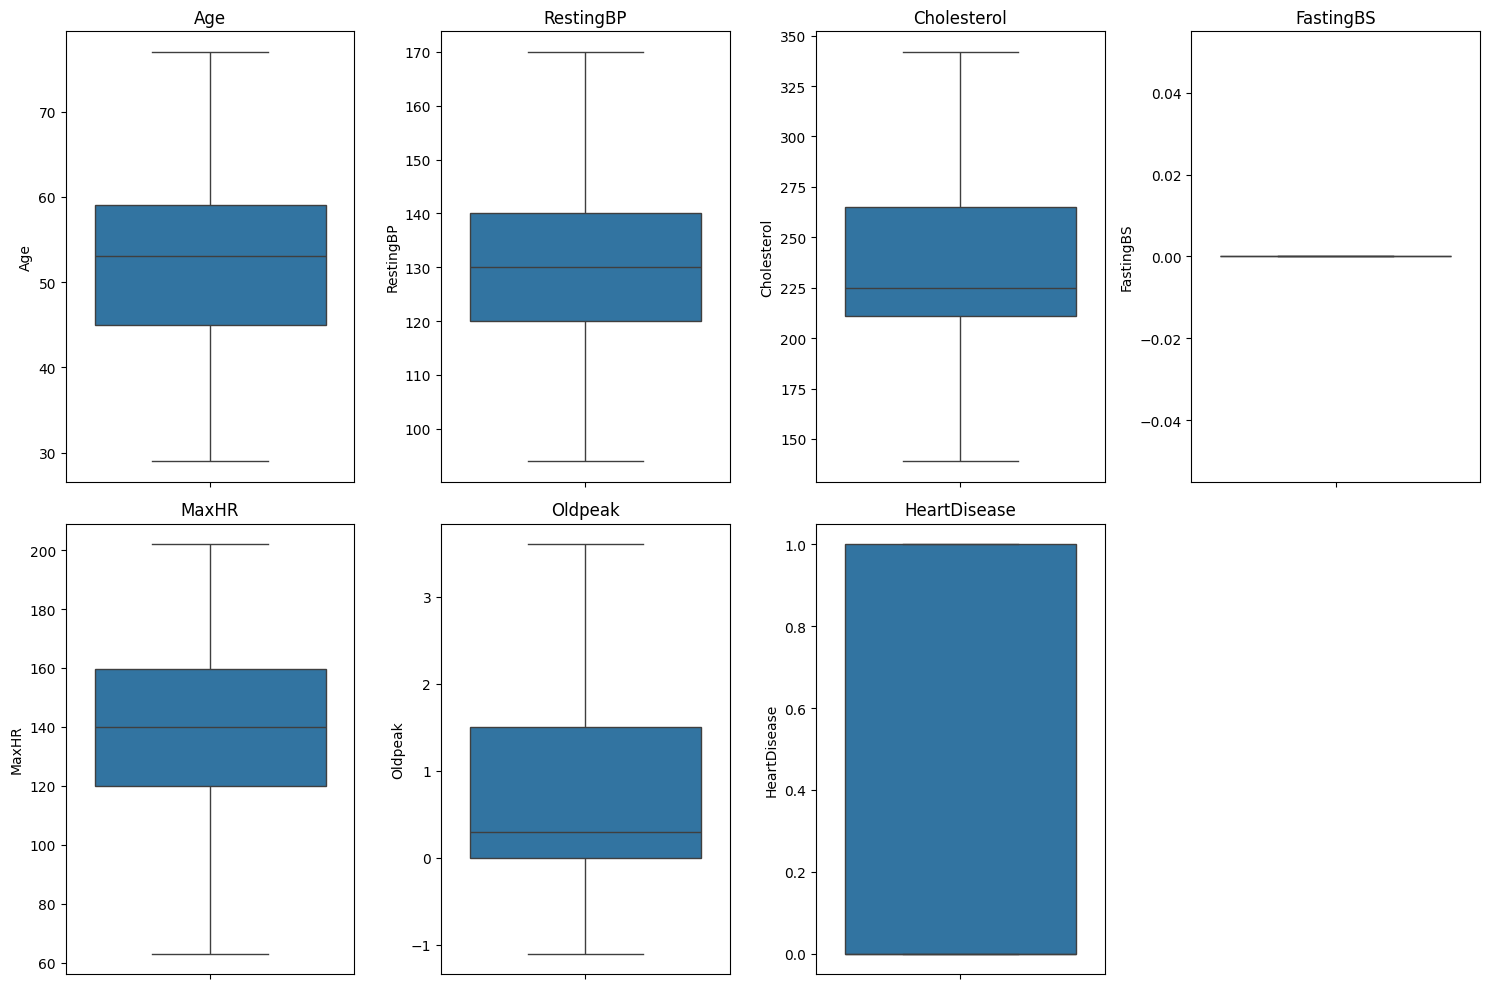

In [ ]:
# Create box plots for each numerical column to visualize outliers
numerical_cols_cleaned = df_cleaned.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_cleaned):
    plt.subplot(len(numerical_cols_cleaned) // 4 + 1, 4, i + 1)
    sns.boxplot(y=df_cleaned[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Analyze relationships with target variable





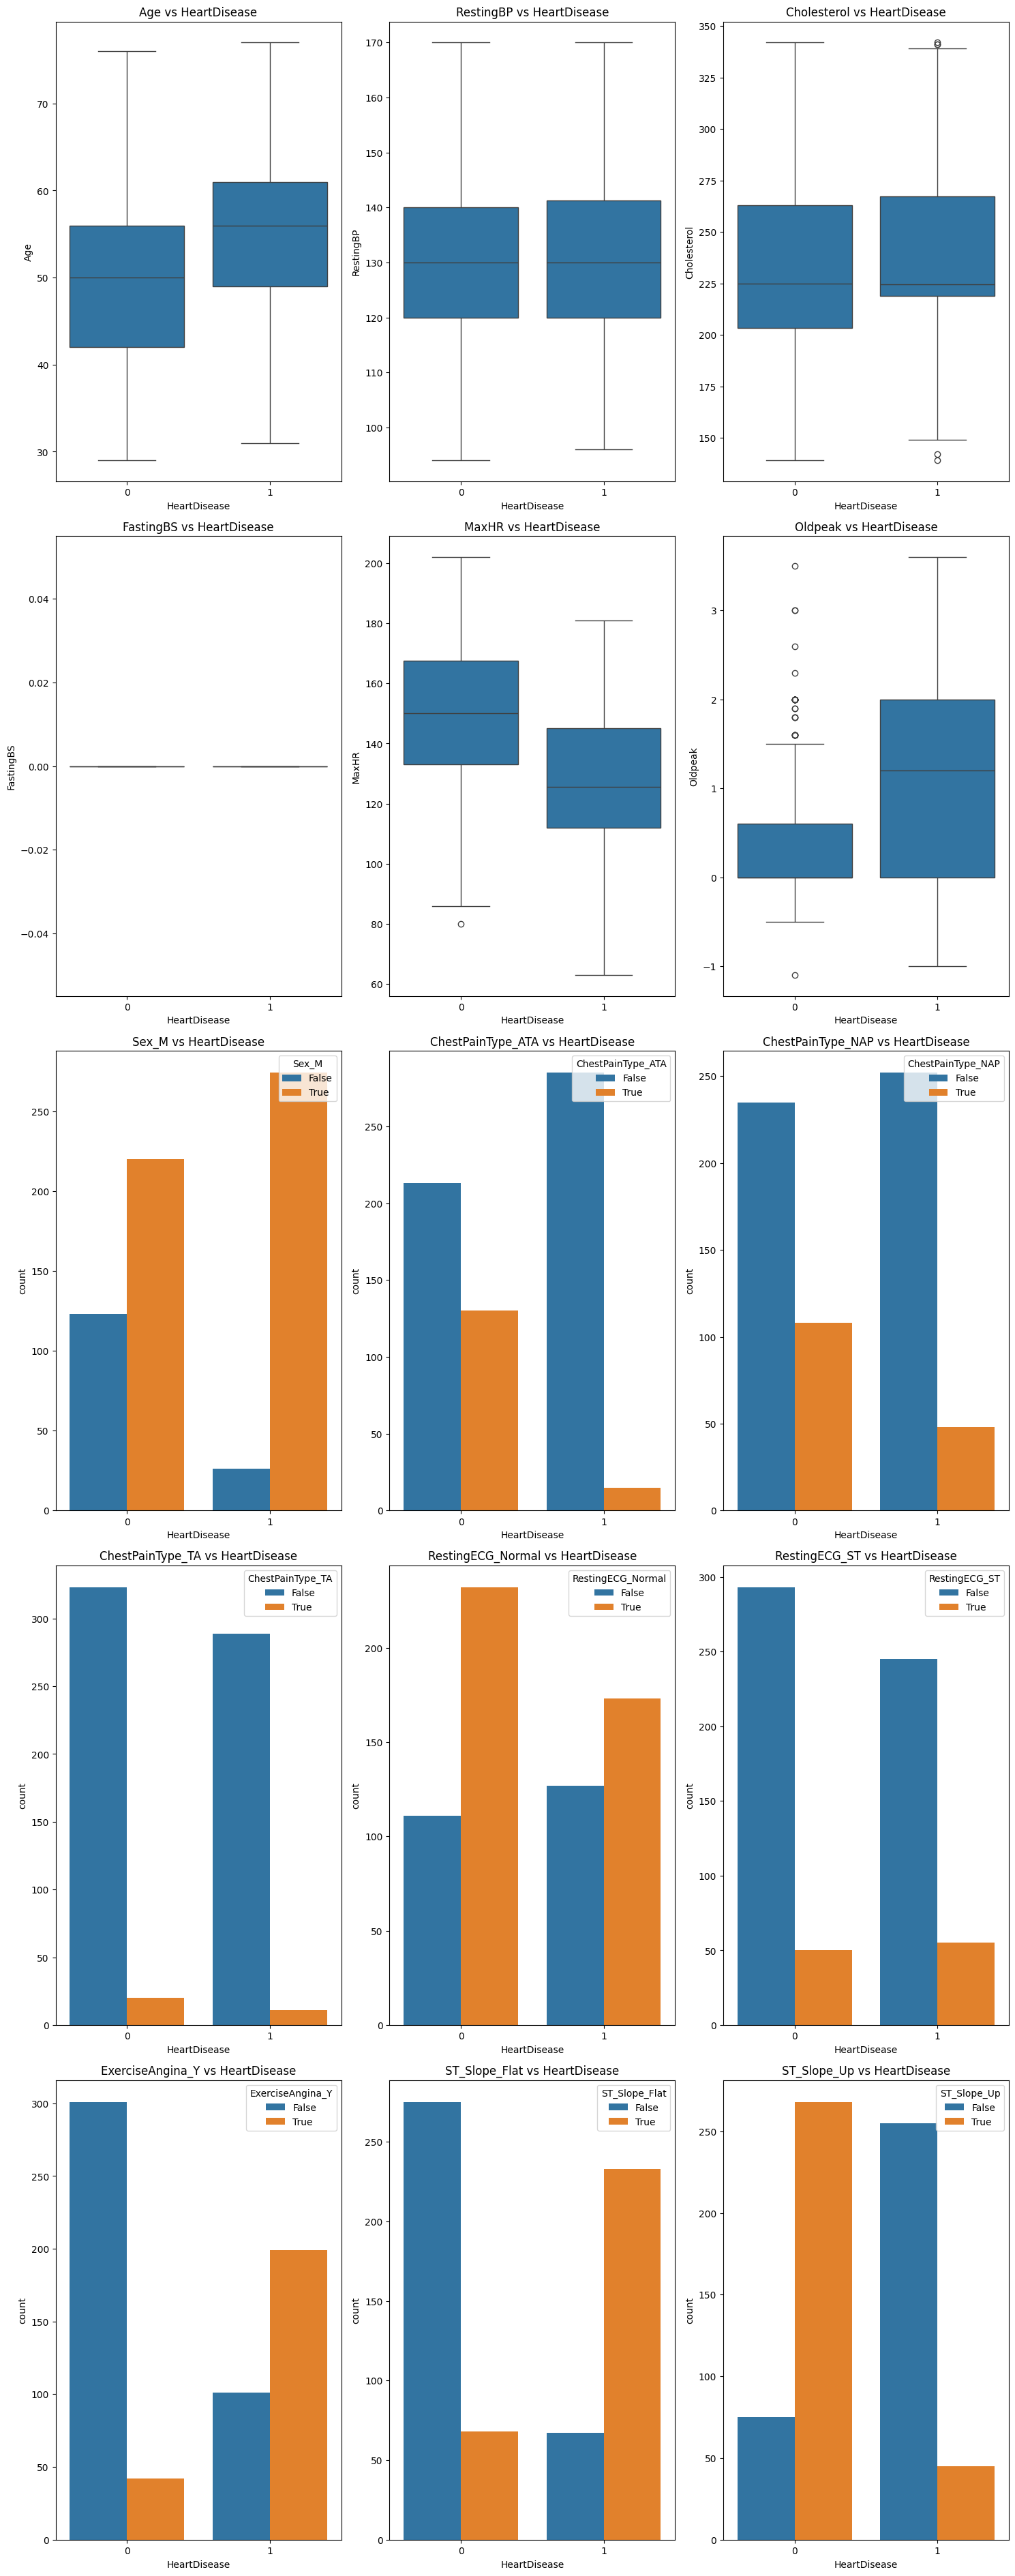

In [ ]:
# Explore the relationship of each feature with the target variable 'HeartDisease'
features = df_cleaned.columns.tolist()
features.remove('HeartDisease')

plt.figure(figsize=(15, len(features) * 3)) # Adjust figure size based on number of features

for i, col in enumerate(features):
    plt.subplot(len(features) // 3 + 1, 3, i + 1)
    if df_cleaned[col].dtype in ['int64', 'float64', 'int32']:
        # Box plot for numerical columns
        sns.boxplot(x='HeartDisease', y=col, data=df_cleaned)
        plt.title(f'{col} vs HeartDisease')
    else:
        # Count plot for categorical columns
        sns.countplot(x='HeartDisease', hue=col, data=df_cleaned)
        plt.title(f'{col} vs HeartDisease')
        plt.xticks(rotation=0) # Keep x-ticks horizontal for HeartDisease (0 or 1)
        plt.legend(title=col, loc='upper right') # Add legend for hue

plt.tight_layout()
plt.show()

## Examine correlations


Re-examine the correlation matrix with the cleaned data to identify strong correlations between features and with the target variable.


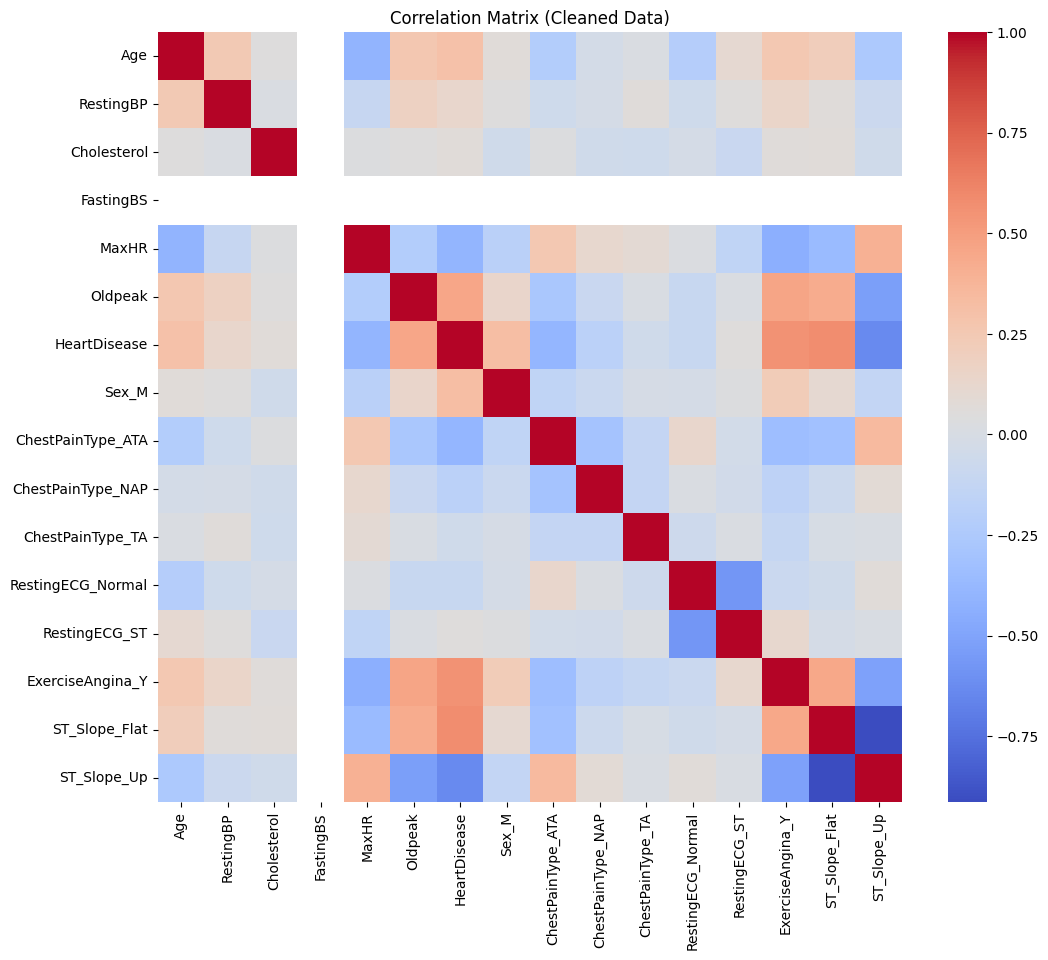

In [ ]:
# Calculate the correlation matrix for the cleaned data
correlation_matrix_cleaned = df_cleaned.corr()

# Create a heatmap visualization of the correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix_cleaned, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix (Cleaned Data)')
plt.show()

## Identify potential feature interactions




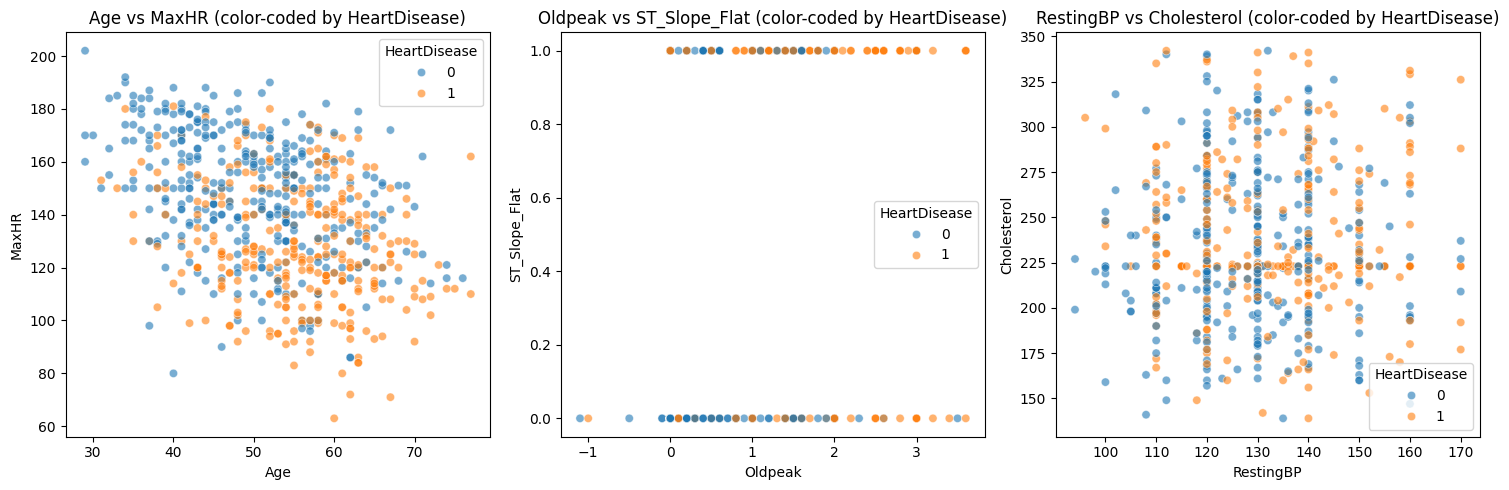

In [ ]:
# Visualize potential interactions between numerical features and the target variable
numerical_cols = df_cleaned.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('HeartDisease')

# Select a few pairs for visualization that might show interactions
# Based on previous correlation analysis and domain knowledge
interaction_pairs = [
    ('Age', 'MaxHR'),
    ('Oldpeak', 'ST_Slope_Flat'), # Using ST_Slope_Flat as it was highly correlated with Oldpeak
    ('RestingBP', 'Cholesterol')
]

plt.figure(figsize=(15, 5))

for i, (col1, col2) in enumerate(interaction_pairs):
    plt.subplot(1, len(interaction_pairs), i + 1)
    sns.scatterplot(data=df_cleaned, x=col1, y=col2, hue='HeartDisease', alpha=0.6)
    plt.title(f'{col1} vs {col2} (color-coded by HeartDisease)')
    plt.xlabel(col1)
    plt.ylabel(col2)

plt.tight_layout()
plt.show()


Created group visualizations to explore if the relationship between a numerical feature and the target variable changes across different categories of a categorical feature.



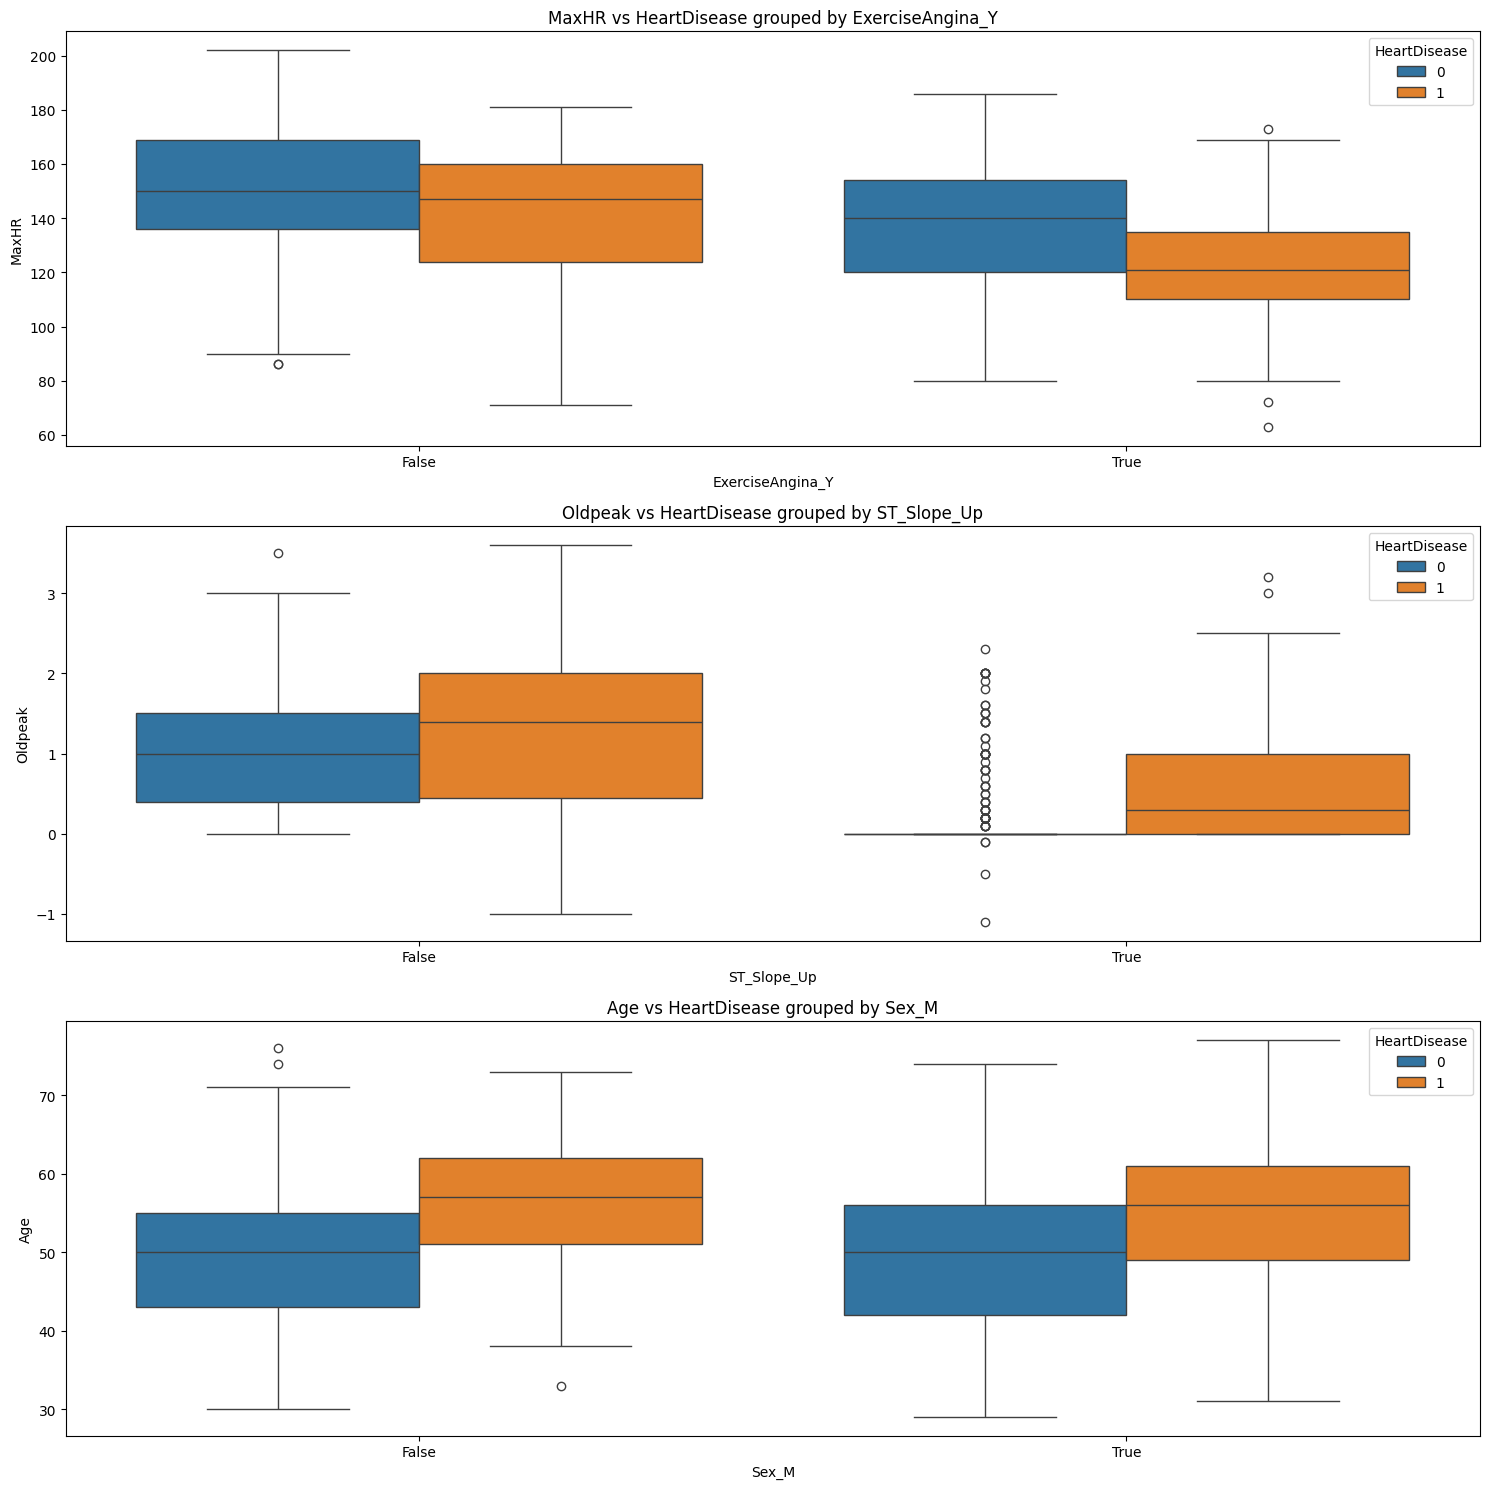

In [ ]:
# Explore potential interactions between numerical and categorical features by grouping
categorical_cols = df_cleaned.select_dtypes(include='bool').columns.tolist()
numerical_cols = df_cleaned.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('HeartDisease')


interaction_combinations = [
    ('MaxHR', 'ExerciseAngina_Y'),
    ('Oldpeak', 'ST_Slope_Up'),
    ('Age', 'Sex_M')
]

plt.figure(figsize=(15, 5 * len(interaction_combinations)))

for i, (num_col, cat_col) in enumerate(interaction_combinations):
    plt.subplot(len(interaction_combinations), 1, i + 1)
    sns.boxplot(data=df_cleaned, x=cat_col, y=num_col, hue='HeartDisease')
    plt.title(f'{num_col} vs HeartDisease grouped by {cat_col}')
    plt.xlabel(cat_col)
    plt.ylabel(num_col)
    plt.legend(title='HeartDisease')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Use mutual_info to capture nonlinear relationships
selector = SelectKBest(score_func=mutual_info_classif, k='all')
selector.fit(X, y)

# Scores
scores_df = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print("SelectKBest Feature Scores")
display(scores_df)



SelectKBest Feature Scores


,Feature,Score
14,ST_Slope_Up,0.201790
13,ST_Slope_Flat,0.190298
12,ExerciseAngina_Y,0.173993
7,ChestPainType_ATA,0.113535
5,Oldpeak,0.106170
4,MaxHR,0.095308
2,Cholesterol,0.048274
6,Sex_M,0.047255
0,Age,0.045763
3,FastingBS,0.036048


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(" Random Forest Feature Importances")
display(importances_df)


 Random Forest Feature Importances


,Feature,Importance
14,ST_Slope_Up,0.167229
4,MaxHR,0.128971
5,Oldpeak,0.101948
12,ExerciseAngina_Y,0.099891
13,ST_Slope_Flat,0.099670
0,Age,0.097204
2,Cholesterol,0.082210
1,RestingBP,0.076764
6,Sex_M,0.046626
7,ChestPainType_ATA,0.039694


In [ ]:
top_rf_features = importances_df['Feature'].head(10).tolist()


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

logreg = LogisticRegression(max_iter=1000)
rfe = RFE(logreg, n_features_to_select=10)
rfe.fit(X, y)

rfe_features = X.columns[rfe.support_].tolist()
print(" Top 10 Features Selected by RFE")
print(rfe_features)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


 Top 10 Features Selected by RFE
['Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


In [ ]:
X_selected = X[rfe_features]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, stratify=y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Initialize models
log_model = LogisticRegression()
tree_model = DecisionTreeClassifier(random_state=42)

# Train models
log_model.fit(X_train_scaled, y_train)
tree_model.fit(X_train_scaled, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n {name} Evaluation Metrics:")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}")
    print(f"Precision: {precision_score(y_test, y_pred):.2f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.2f}")
    print(f"F1 Score : {f1_score(y_test, y_pred):.2f}")
    print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.2f}")

# Evaluate both models
evaluate_model("Logistic Regression", log_model, X_test_scaled, y_test)
evaluate_model("Decision Tree", tree_model, X_test_scaled, y_test)



 Logistic Regression Evaluation Metrics:
Accuracy : 0.88
Precision: 0.87
Recall   : 0.88
F1 Score : 0.88
ROC AUC  : 0.95

 Decision Tree Evaluation Metrics:
Accuracy : 0.84
Precision: 0.83
Recall   : 0.83
F1 Score : 0.83
ROC AUC  : 0.88


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n Random Forest Evaluation Metrics:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.2f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.2f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.2f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_rf):.2f}")



🔹 Random Forest Evaluation Metrics:
Accuracy : 0.87
Precision: 0.83
Recall   : 0.90
F1 Score : 0.86
ROC AUC  : 0.94


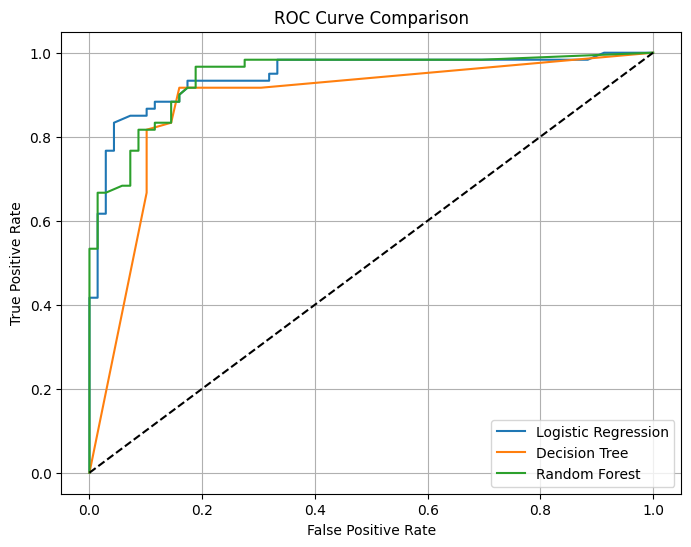

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test_scaled)[:, 1])
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_model.predict_proba(X_test_scaled)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_tree, tpr_tree, label='Decision Tree')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()
